# Semiconductor Manufacturing Fault Detection (SECOM)


**Dataset:** SECOM (UCI Machine Learning Repository) — real, anonymized sensor data from a semiconductor
manufacturing line, 1,567 production units, 590 sensor measurements each, 6.64% failure rate.

**What this notebook does:** builds an unsupervised anomaly detector (Isolation Forest) that never sees a
single labeled failure during training, benchmarks it against two familiar supervised models (Logistic
Regression, Random Forest), explains the supervised model's predictions with SHAP, and the most important
technical result in this notebook shows that a naive random train/test split produces a badly misleading
performance estimate on this dataset, and demonstrates the fix.

At the end applies PCA and Hotelling's T² (Multivariate Analysis ) to the
same problem, for comparison against the ML-based approach done before.


---

## 1. Load Data and Explore

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
import os
import urllib.request

DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data'
LABELS_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data'

def download_if_needed(url, path, min_bytes):
    """Download a file only if it's missing or clearly incomplete, and fail loudly
    and clearly rather than silently leaving pd.read_csv to throw a confusing
    EmptyDataError. wget -q swallows network errors; this doesn't."""
    if os.path.exists(path) and os.path.getsize(path) >= min_bytes:
        print(f'{path} already present ({os.path.getsize(path):,} bytes) — skipping download.')
        return
    print(f'Downloading {url} ...')
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(
            f'Failed to download {url}.\n'
            f'This is usually a network issue or a temporarily unavailable UCI server, not a bug '
            f'in this notebook. Re-run this cell, or manually download the file from the UCI SECOM '
            f'page (https://archive.ics.uci.edu/ml/datasets/SECOM) and save it as: {path}\n'
            f'Original error: {e}'
        ) from e

    actual_size = os.path.getsize(path) if os.path.exists(path) else 0
    if actual_size < min_bytes:
        if os.path.exists(path):
            os.remove(path)  # don't leave a corrupt partial file for the next run to wrongly "trust"
        raise RuntimeError(
            f'Download of {url} produced an incomplete file '
            f'(expected at least {min_bytes:,} bytes, got {actual_size:,}). '
            f'The partial file has been removed — re-run this cell, or download manually.'
        )
    print(f'Downloaded {path} ({actual_size:,} bytes).')

# Real file sizes are ~2.99 MB (data) and ~26 KB (labels); thresholds set well below that
# so a genuine, complete download always passes, but a near-empty failed download doesn't.
download_if_needed(DATA_URL, 'secom_data.data', min_bytes=500_000)
download_if_needed(LABELS_URL, 'secom_labels.data', min_bytes=5_000)

try:
    X = pd.read_csv('secom_data.data', sep=r'\s+', header=None)
except pd.errors.EmptyDataError as e:
    raise RuntimeError(
        'secom_data.data exists but pandas could not read it as CSV — it may be corrupted. '
        'Delete secom_data.data and re-run this cell to re-download.'
    ) from e

X.columns = [f'sensor_{i}' for i in range(X.shape[1])]

labels_raw = pd.read_csv('secom_labels.data', sep=r'\s+', header=None, names=['label', 'timestamp'])
y_binary = (labels_raw['label'] == 1).astype(int)   # SECOM encodes fail=1, pass=-1 -> remap to 0/1
timestamp = pd.to_datetime(labels_raw['timestamp'], dayfirst=True, errors='coerce')

print('Shape:', X.shape)
print('Fail rate: {:.2f}%'.format(100 * y_binary.mean()))




Downloaded secom_data.data (5,389,983 bytes).
Downloaded secom_labels.data (40,638 bytes).
Shape: (1567, 590)
Fail rate: 6.64%




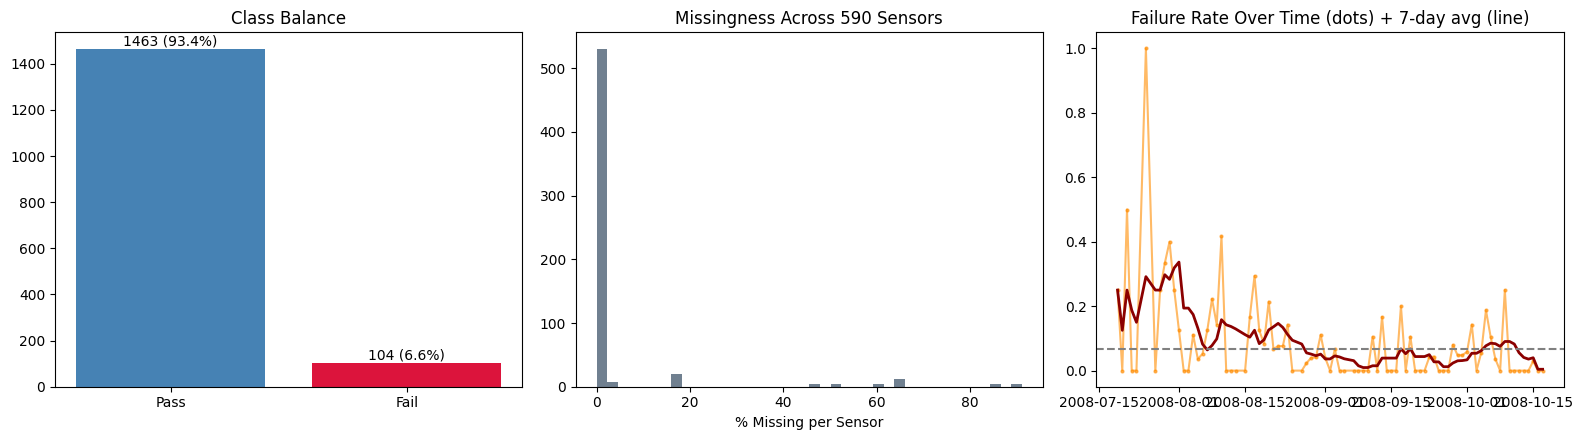

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Class balance
counts = y_binary.value_counts().sort_index()
axes[0].bar(['Pass', 'Fail'], counts.values, color=['steelblue', 'crimson'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f'{v} ({100*v/counts.sum():.1f}%)', ha='center')
axes[0].set_title('Class Balance')

# Missingness
missing_pct = X.isnull().mean() * 100
axes[1].hist(missing_pct, bins=40, color='slategray')
axes[1].set_xlabel('% Missing per Sensor')
axes[1].set_title('Missingness Across 590 Sensors')

# Failure rate over time
daily = pd.DataFrame({'ts': timestamp, 'label': y_binary}).set_index('ts').resample('D')['label'].mean().dropna()
axes[2].plot(daily.index, daily.values, color='darkorange', marker='o', markersize=2, alpha=0.6)
axes[2].plot(daily.index, daily.rolling(7, min_periods=1).mean(), color='darkred', linewidth=2)
axes[2].axhline(y_binary.mean(), color='gray', linestyle='--')
axes[2].set_title('Failure Rate Over Time (dots) + 7-day avg (line)')

plt.tight_layout()
plt.show()


---

## 2. Preprocessing — and the Split That Almost Fooled Me


In [ ]:
# Sort chronologically
order = timestamp.sort_values(kind='mergesort').index
X_sorted = X.loc[order].reset_index(drop=True)
y_sorted = y_binary.loc[order].reset_index(drop=True)
ts_sorted = timestamp.loc[order].reset_index(drop=True)

split_idx = int(0.75 * len(X_sorted))
X_train_raw, X_test_raw = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f'Train: {len(X_train_raw)} units, fail rate {y_train.mean():.4f} ({y_train.sum()} failures)')
print(f'Test:  {len(X_test_raw)} units, fail rate {y_test.mean():.4f} ({y_test.sum()} failures)')




Train: 1175 units, fail rate 0.0681 (80 failures)
Test:  392 units, fail rate 0.0612 (24 failures)




**Cleaning decisions — fit on training data only.**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

MISSING_THRESHOLD = 40  # % missing above which a sensor is dropped

missing_pct_train = X_train_raw.isnull().mean() * 100
cols_to_keep = missing_pct_train[missing_pct_train <= MISSING_THRESHOLD].index
X_train_reduced = X_train_raw[cols_to_keep]
zero_var = X_train_reduced.columns[X_train_reduced.nunique(dropna=True) <= 1]
X_train_reduced = X_train_reduced.drop(columns=zero_var)
X_test_reduced = X_test_raw[X_train_reduced.columns]

print(f'Sensors kept: {X_train_reduced.shape[1]} / {X.shape[1]}')

imputer = SimpleImputer(strategy='median').fit(X_train_reduced)
X_train_imp = pd.DataFrame(imputer.transform(X_train_reduced), columns=X_train_reduced.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test_reduced), columns=X_test_reduced.columns)

scaler = StandardScaler().fit(X_train_imp)
X_train = pd.DataFrame(scaler.transform(X_train_imp), columns=X_train_imp.columns)
X_test = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

print('Final shapes:', X_train.shape, X_test.shape)




Sensors kept: 440 / 590
Final shapes: (1175, 440) (392, 440)




---

## 3. Isolation Forest — Unsupervised Anomaly Detection



In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve

X_train_incontrol = X_train[y_train.values == 0]   # passing units only

iso_forest = IsolationForest(n_estimators=300, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_train_incontrol)

# decision_function: higher = more normal. Flip sign so higher = more anomalous, matching AP's convention.
iso_scores_test = -iso_forest.decision_function(X_test)
iso_ap = average_precision_score(y_test, iso_scores_test)

print(f'Isolation Forest (unsupervised, no failure labels seen) — Average Precision: {iso_ap:.3f}')




Isolation Forest (unsupervised, no failure labels seen) — Average Precision: 0.072




---

## 4. Supervised Benchmarks: Logistic Regression + Random Forest



In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

tscv = TimeSeriesSplit(n_splits=5)

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.3],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='average_precision',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_
print('Best hyperparameters found (TimeSeriesSplit on training data only):')
print(best_rf_params)
print(f'Best cross-validated Average Precision: {rf_search.best_score_:.3f}')




Best hyperparameters found (TimeSeriesSplit on training data only):
{'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 10}
Best cross-validated Average Precision: 0.175




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)
logreg_probs = logreg.predict_proba(X_test)[:, 1]
logreg_ap = average_precision_score(y_test, logreg_probs)

# Uses best_rf_params found above via TimeSeriesSplit — not the earlier hardcoded n_estimators=300
rf = RandomForestClassifier(**best_rf_params, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_ap = average_precision_score(y_test, rf_probs)

print(f'Logistic Regression \u2014 Average Precision: {logreg_ap:.3f}')
print(f'Random Forest       \u2014 Average Precision: {rf_ap:.3f}')
print()
print('Random Forest classification report at default 0.5 threshold (see the threshold analysis below for why this is not the primary evaluation):')
print(classification_report(y_test, rf.predict(X_test), target_names=['Pass', 'Fail'], zero_division=0))




Logistic Regression — Average Precision: 0.082
Random Forest       — Average Precision: 0.067

Random Forest classification report at default 0.5 threshold (see the threshold analysis below for why this is not the primary evaluation):
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       368
        Fail       0.00      0.00      0.00        24

    accuracy                           0.94       392
   macro avg       0.47      0.50      0.48       392
weighted avg       0.88      0.94      0.91       392





### Threshold Analysis — Replacing the Arbitrary 0.5 Cutoff




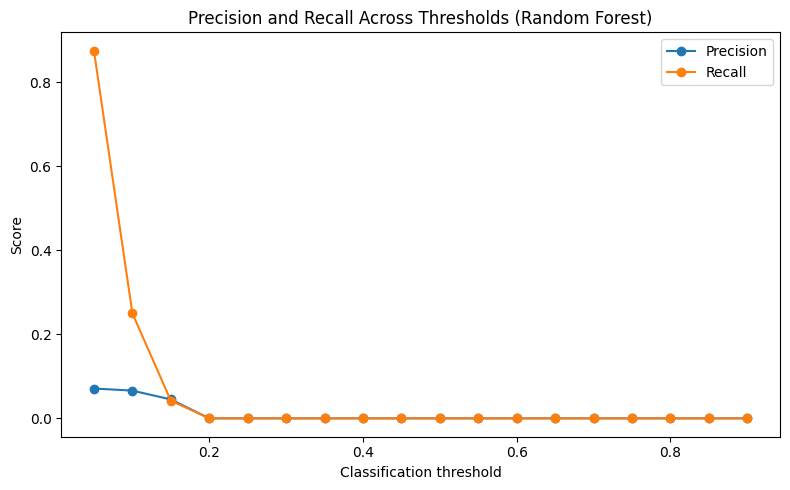

,threshold,precision,recall,flagged,true_positives,false_positives,false_negatives
0,0.05,0.071,0.875,294,21,273,3
1,0.10,0.066,0.250,91,6,85,18
2,0.15,0.045,0.042,22,1,21,23
3,0.20,0.000,0.000,3,0,3,24
4,0.25,0.000,0.000,1,0,1,24
5,0.30,0.000,0.000,1,0,1,24
6,0.35,0.000,0.000,0,0,0,24
7,0.40,0.000,0.000,0,0,0,24
8,0.45,0.000,0.000,0,0,0,24
9,0.50,0.000,0.000,0,0,0,24


In [ ]:
thresholds = np.arange(0.05, 0.95, 0.05)
threshold_rows = []
for t in thresholds:
    preds_at_t = (rf_probs >= t).astype(int)
    tp = ((preds_at_t == 1) & (y_test.values == 1)).sum()
    fp = ((preds_at_t == 1) & (y_test.values == 0)).sum()
    fn = ((preds_at_t == 0) & (y_test.values == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    threshold_rows.append({'threshold': round(t, 2), 'precision': round(precision, 3),
                            'recall': round(recall, 3), 'flagged': int(preds_at_t.sum()),
                            'true_positives': int(tp), 'false_positives': int(fp), 'false_negatives': int(fn)})

threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Across Thresholds (Random Forest)')
ax.legend()
plt.tight_layout()
plt.show()

threshold_df


In [ ]:
MIN_PRECISION = 0.10  # illustrative floor, not a validated business constraint

viable = threshold_df[threshold_df['precision'] >= MIN_PRECISION]
if len(viable) > 0:
    chosen = viable.loc[viable['recall'].idxmax()]
    print(f'Chosen threshold: {chosen["threshold"]} — Precision: {chosen["precision"]}, '
          f'Recall: {chosen["recall"]}, Flagged: {int(chosen["flagged"])} units')
else:
    print(f'No threshold in the tested range keeps precision above {MIN_PRECISION} — '
          f'widen the threshold range or lower MIN_PRECISION.')




No threshold in the tested range keeps precision above 0.1 — widen the threshold range or lower MIN_PRECISION.




---

## 5. Evaluation: Precision-Recall Curves and Confidence Intervals

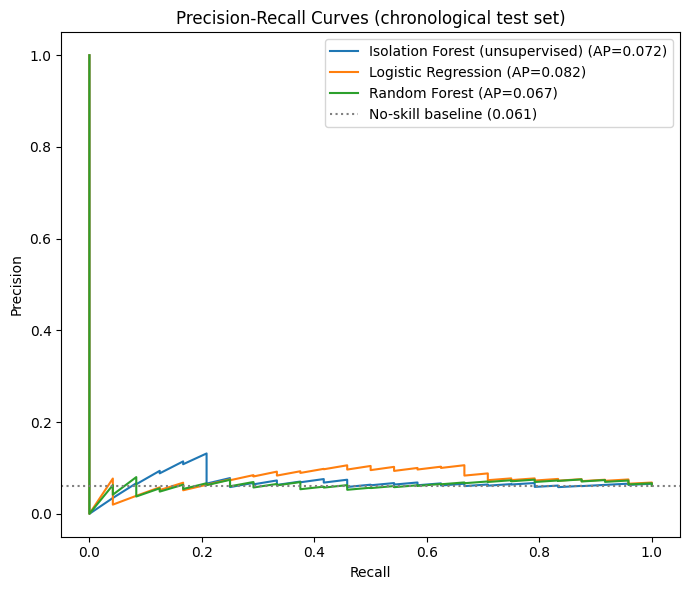

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, scores, ap in [
    ('Isolation Forest (unsupervised)', iso_scores_test, iso_ap),
    ('Logistic Regression', logreg_probs, logreg_ap),
    ('Random Forest', rf_probs, rf_ap),
]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle=':', label=f'No-skill baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (chronological test set)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
def bootstrap_ap_ci(y_true, scores, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)
    boot_aps = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_b = y_true[idx]
        if y_b.sum() == 0 or y_b.sum() == n:
            continue
        boot_aps.append(average_precision_score(y_b, scores[idx]))
    return np.percentile(boot_aps, 2.5), np.percentile(boot_aps, 97.5)

results_table = []
for name, scores, ap in [
    ('Isolation Forest', iso_scores_test, iso_ap),
    ('Logistic Regression', logreg_probs, logreg_ap),
    ('Random Forest', rf_probs, rf_ap),
]:
    lo, hi = bootstrap_ap_ci(y_test.values, np.asarray(scores))
    results_table.append({'Model': name, 'AP': round(ap, 3), '95% CI': f'[{lo:.3f}, {hi:.3f}]'})

pd.DataFrame(results_table)


,Model,AP,95% CI
0,Isolation Forest,0.072,"[0.044, 0.125]"
1,Logistic Regression,0.082,"[0.053, 0.138]"
2,Random Forest,0.067,"[0.042, 0.119]"


---

## 6. The Headline Finding: Random Split vs. Chronological Split



In [ ]:
from sklearn.model_selection import train_test_split

# Random split, for comparison only — reusing the same cleaning pipeline shape, fit fresh on this split
X_train_rand_raw, X_test_rand_raw, y_train_rand, y_test_rand = train_test_split(
    X_sorted, y_sorted, test_size=0.25, stratify=y_sorted, random_state=42
)

missing_pct_rand = X_train_rand_raw.isnull().mean() * 100
cols_rand = missing_pct_rand[missing_pct_rand <= MISSING_THRESHOLD].index
X_train_rand_reduced = X_train_rand_raw[cols_rand]
zero_var_rand = X_train_rand_reduced.columns[X_train_rand_reduced.nunique(dropna=True) <= 1]
X_train_rand_reduced = X_train_rand_reduced.drop(columns=zero_var_rand)
X_test_rand_reduced = X_test_rand_raw[X_train_rand_reduced.columns]

imputer_rand = SimpleImputer(strategy='median').fit(X_train_rand_reduced)
X_train_rand_imp = pd.DataFrame(imputer_rand.transform(X_train_rand_reduced), columns=X_train_rand_reduced.columns)
X_test_rand_imp = pd.DataFrame(imputer_rand.transform(X_test_rand_reduced), columns=X_test_rand_reduced.columns)

scaler_rand = StandardScaler().fit(X_train_rand_imp)
X_train_rand = pd.DataFrame(scaler_rand.transform(X_train_rand_imp), columns=X_train_rand_imp.columns)
X_test_rand = pd.DataFrame(scaler_rand.transform(X_test_rand_imp), columns=X_test_rand_imp.columns)

# Uses the SAME tuned hyperparameters as the chronological-split model above (best_rf_params),
# so split strategy is the only thing that differs between this comparison and Section 4's result —
# a different hyperparameter set here would confound the comparison this section exists to make.
rf_rand = RandomForestClassifier(**best_rf_params, class_weight='balanced', random_state=42, n_jobs=-1)
rf_rand.fit(X_train_rand, y_train_rand)
rf_rand_probs = rf_rand.predict_proba(X_test_rand)[:, 1]
rf_rand_ap = average_precision_score(y_test_rand, rf_rand_probs)

print(f'Random Forest — RANDOM split:        AP = {rf_rand_ap:.3f}')
print(f'Random Forest — CHRONOLOGICAL split: AP = {rf_ap:.3f}')
print(f'\nDifference: {rf_rand_ap - rf_ap:+.3f} — the random split makes the model look '
      f'{"substantially better" if rf_rand_ap > rf_ap else "worse"} than the chronological split does.')




Random Forest — RANDOM split:        AP = 0.161
Random Forest — CHRONOLOGICAL split: AP = 0.067

Difference: +0.093 — the random split makes the model look substantially better than the chronological split does.




---

## 7.  SHAP on Random Forest





Model classes (index -> label): {0: np.int64(0), 1: np.int64(1)}
SHAP values shape: (392, 440, 2) (ndim=3)




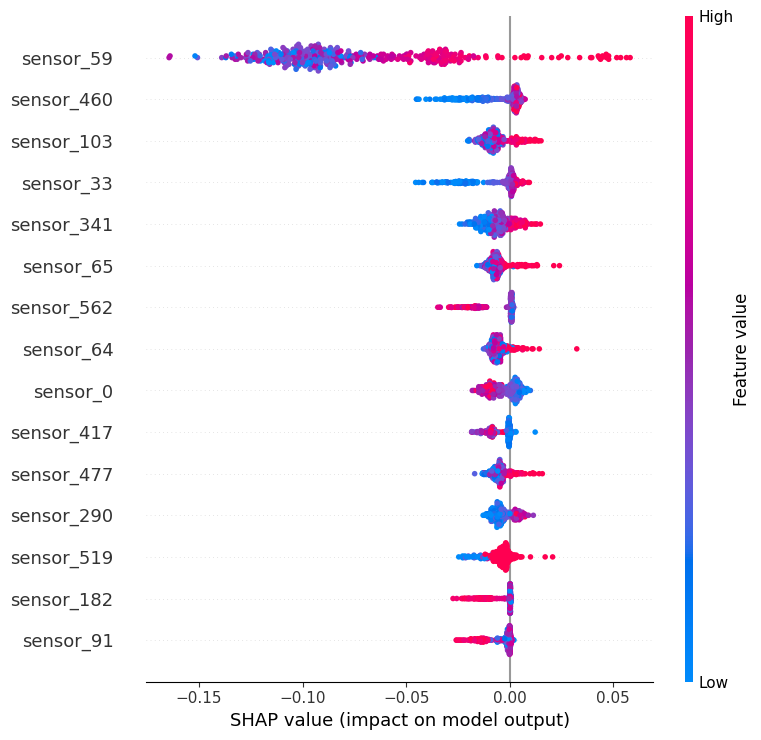

In [ ]:
# pip install shap --break-system-packages   (uncomment if not already installed)
import shap

explainer = shap.TreeExplainer(rf)
raw_shap = explainer(X_test)

def get_positive_class_shap(explanation, positive_class_index=1):
    """TreeExplainer's output shape for a binary classifier varies by SHAP version and
    how the model wraps its output: some versions return a 3D array
    (n_samples, n_features, n_classes), others return 2D (n_samples, n_features) already
    for the positive class. Rather than assuming one shape (which breaks silently or
    loudly depending on version), this checks the actual shape at runtime and handles both."""
    values = explanation.values
    print(f'SHAP values shape: {values.shape} (ndim={values.ndim})')
    if values.ndim == 3:
        # (n_samples, n_features, n_classes) -> take the positive ("Fail") class slice
        n_classes = values.shape[2]
        if positive_class_index >= n_classes:
            raise ValueError(f'Requested class index {positive_class_index} but model only has '
                              f'{n_classes} output classes — check rf.classes_ to confirm which '
                              f'index corresponds to the failure class.')
        return explanation[:, :, positive_class_index]
    elif values.ndim == 2:
        # Already (n_samples, n_features) for a single output — use as-is
        return explanation
    else:
        raise ValueError(f'Unexpected SHAP values shape {values.shape} (ndim={values.ndim}) — '
                          f'this SHAP version returned something this notebook doesn\'t handle. '
                          f'Inspect explainer(X_test).values directly and adjust get_positive_class_shap().')

print('Model classes (index -> label):', dict(enumerate(rf.classes_)))
shap_values_pos = get_positive_class_shap(raw_shap, positive_class_index=1)

# Global view: which sensors matter most across all predictions?
shap.summary_plot(shap_values_pos, X_test, max_display=15, show=True)




Explaining prediction for test unit index 10 (actual label: Fail)
Model predicted failure probability: 0.045




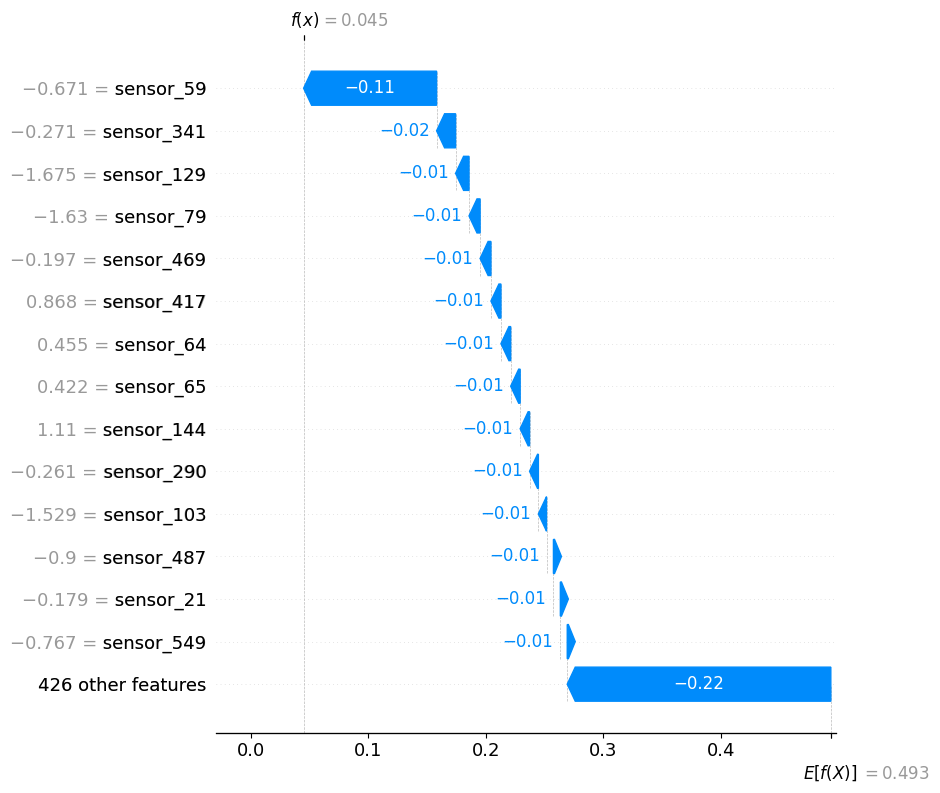

In [ ]:
# Local view: explain one specific correctly-flagged failure
fail_idx = np.where(y_test.values == 1)[0]
if len(fail_idx) > 0:
    example_idx = fail_idx[0]
    print(f'Explaining prediction for test unit index {example_idx} (actual label: Fail)')
    print(f'Model predicted failure probability: {rf_probs[example_idx]:.3f}')
    shap.plots.waterfall(shap_values_pos[example_idx], max_display=15)
else:
    print('No failures in test set to explain individually.')


---

## 8. Multivariate Analysis (PCA + Hotelling's T² + LDA)



### PCA


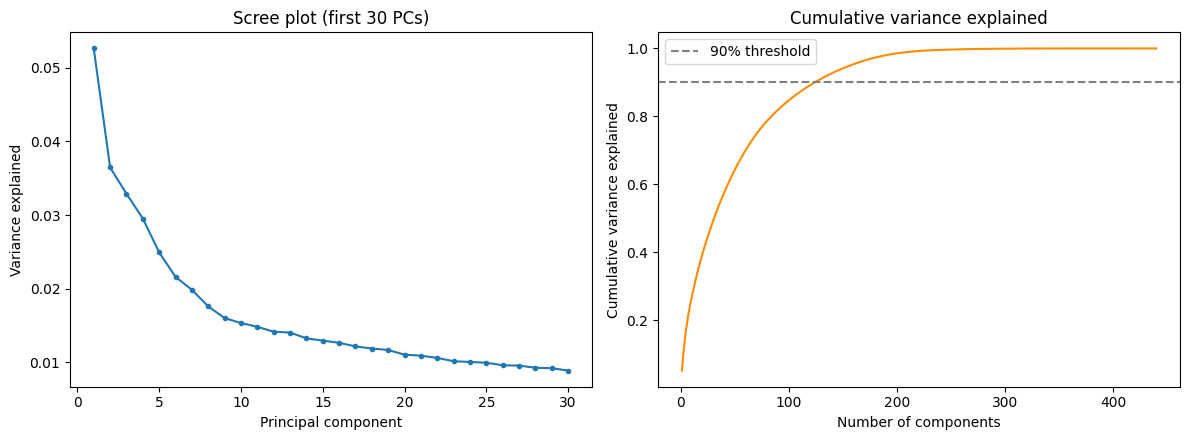

In [ ]:
from sklearn.decomposition import PCA

pca_full_scan = PCA()
pca_full_scan.fit(X_train_incontrol)
cum_var = np.cumsum(pca_full_scan.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(range(1, 31), pca_full_scan.explained_variance_ratio_[:30], marker='o', markersize=3)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained')
axes[0].set_title('Scree plot (first 30 PCs)')

axes[1].plot(range(1, len(cum_var) + 1), cum_var, color='darkorange')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title('Cumulative variance explained')
axes[1].legend()
plt.tight_layout()
plt.show()


**Sensitivity check.** Rather than just asserting 90% is fine, this refits PCA at 80%, 90%, and 95% variance retained and checks how much the number of components and Hotelling's T²'s detection ability actually changes.


In [ ]:
from scipy.stats import f as f_dist

def hotelling_t2(scores, eigenvalues):
    return np.sum((scores ** 2) / eigenvalues, axis=1)

sensitivity_rows = []
for variance_target in [0.80, 0.90, 0.95]:
    pca_s = PCA(n_components=variance_target)
    pca_s.fit(X_train_incontrol)
    eig_s = pca_s.explained_variance_
    scores_train_s = pca_s.transform(X_train_incontrol)

    n_s, k_s = X_train_incontrol.shape[0], pca_s.n_components_
    limit_s = (k_s * (n_s - 1) / (n_s - k_s)) * f_dist.ppf(0.95, k_s, n_s - k_s)

    t2_test_s = hotelling_t2(pca_s.transform(X_test), eig_s)
    ap_s = average_precision_score(y_test, t2_test_s)

    sensitivity_rows.append({'variance_retained': variance_target, 'n_components': k_s,
                              'control_limit': round(limit_s, 2), 'T2_average_precision': round(ap_s, 3)})

pd.DataFrame(sensitivity_rows)


,variance_retained,n_components,control_limit,T2_average_precision
0,0.80,84,116.50,0.058
1,0.90,124,172.61,0.062
2,0.95,157,222.03,0.062


### Hotelling's T²
**Phase I — building the model.**

**Phase II — monitoring new observations.**


In [ ]:
from sklearn.decomposition import PCA
from scipy.stats import f as f_dist

pca = PCA(n_components=0.90)   # retain enough components for 90% of variance
pca.fit(X_train_incontrol)
print(f'Components retained for 90% variance: {pca.n_components_} (out of {X_train.shape[1]} sensors)')

eigenvalues = pca.explained_variance_
scores_train_incontrol = pca.transform(X_train_incontrol)

def hotelling_t2(scores, eigenvalues):
    return np.sum((scores ** 2) / eigenvalues, axis=1)

n, k = X_train_incontrol.shape[0], pca.n_components_
alpha = 0.05
t2_limit = (k * (n - 1) / (n - k)) * f_dist.ppf(1 - alpha, k, n - k)

t2_test = hotelling_t2(pca.transform(X_test), eigenvalues)
t2_ap = average_precision_score(y_test, t2_test)

print(f'Hotelling\'s T\u00b2 control limit (95%, F-distribution): {t2_limit:.2f}')
print(f'Hotelling\'s T\u00b2 — Average Precision: {t2_ap:.3f}  (compare against Section 5 above)')




Components retained for 90% variance: 124 (out of 440 sensors)
Hotelling's T² control limit (95%, F-distribution): 172.61
Hotelling's T² — Average Precision: 0.062  (compare against Section 5 above)




### T² Control Chart



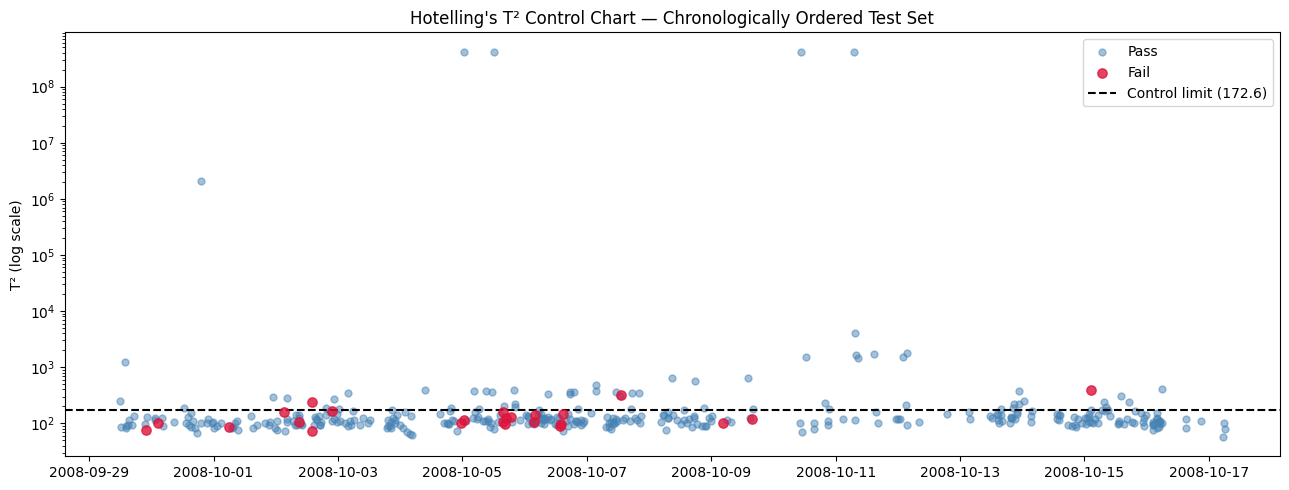

In [ ]:
test_timestamps = ts_sorted.iloc[split_idx:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(test_timestamps[y_test.values == 0], t2_test[y_test.values == 0],
           color='steelblue', alpha=0.5, s=25, label='Pass')
ax.scatter(test_timestamps[y_test.values == 1], t2_test[y_test.values == 1],
           color='crimson', alpha=0.8, s=45, label='Fail', zorder=3)
ax.axhline(t2_limit, color='black', linestyle='--', label=f'Control limit ({t2_limit:.1f})')
ax.set_yscale('log')
ax.set_ylabel('T\u00b2 (log scale)')
ax.set_title('Hotelling\'s T\u00b2 Control Chart \u2014 Chronologically Ordered Test Set')
ax.legend()
plt.tight_layout()
plt.show()


### What Drives the First Few Components



In [ ]:
loadings = pd.DataFrame(pca.components_[:3].T, index=X_train.columns, columns=['PC1', 'PC2', 'PC3'])

for pc in ['PC1', 'PC2', 'PC3']:
    top5 = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f'{pc} \u2014 top 5 sensors by absolute loading:')
    print(loadings.loc[top5.index, pc])
    print()




PC1 — top 5 sensors by absolute loading:
sensor_343    0.197258
sensor_335    0.192563
sensor_332    0.192330
sensor_336    0.192222
sensor_207    0.192013
Name: PC1, dtype: float64

PC2 — top 5 sensors by absolute loading:
sensor_27     0.175046
sensor_25     0.174383
sensor_26     0.157018
sensor_299   -0.142444
sensor_164   -0.141748
Name: PC2, dtype: float64

PC3 — top 5 sensors by absolute loading:
sensor_283    0.209794
sensor_152    0.209751
sensor_287    0.209735
sensor_148    0.209443
sensor_421    0.208531
Name: PC3, dtype: float64





### T² Detection Metrics at the Control Limit


In [ ]:
flagged = t2_test > t2_limit
tp = int(((flagged) & (y_test.values == 1)).sum())
fp = int(((flagged) & (y_test.values == 0)).sum())
tn = int(((~flagged) & (y_test.values == 0)).sum())
fn = int(((~flagged) & (y_test.values == 1)).sum())

recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f'At the control limit ({t2_limit:.2f}):')
print(f'  TP={tp}, FP={fp}, TN={tn}, FN={fn}')
print(f'  Detection rate (recall):  {recall:.1%}')
print(f'  Precision:                {precision:.1%}')
print(f'  False-alarm rate:         {false_alarm_rate:.1%}')
print(f'\nIn SPC terms: the T\u00b2 chart detected {recall:.0%} of failures while flagging '
      f'{false_alarm_rate:.0%} of genuinely passing units as false alarms.')




At the control limit (172.61):
  TP=3, FP=66, TN=302, FN=21
  Detection rate (recall):  12.5%
  Precision:                4.3%
  False-alarm rate:         17.9%

In SPC terms: the T² chart detected 12% of failures while flagging 18% of genuinely passing units as false alarms.




### LDA — Classification Based on Multivariate Normal Distributions



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_train, y_train)
lda_probs = lda.predict_proba(X_test)[:, 1]
lda_ap = average_precision_score(y_test, lda_probs)

print(f'LDA \u2014 Average Precision: {lda_ap:.3f}')
print(f'For comparison \u2014 Logistic Regression: {logreg_ap:.3f}, Random Forest: {rf_ap:.3f}')




LDA — Average Precision: 0.102
For comparison — Logistic Regression: 0.082, Random Forest: 0.067




---

## 9. Export Data for the Tableau Dashboard



In [ ]:
import os
os.makedirs('tableau_exports', exist_ok=True)

# 1. KPI summary — single-row table for the dashboard's headline number cards
all_model_aps = {
    'Isolation Forest': iso_ap,
    'Logistic Regression': logreg_ap,
    'Random Forest': rf_ap,
    'LDA': lda_ap,
}
best_model_name = max(all_model_aps, key=all_model_aps.get)

kpi_summary = pd.DataFrame([{
    'total_units': len(X),
    'fail_rate_pct': round(100 * y_binary.mean(), 2),
    'sensors_retained': X_train.shape[1],
    'sensors_total': X.shape[1],
    'best_model': best_model_name,
    'best_model_ap': round(all_model_aps[best_model_name], 3),
}])
kpi_summary.to_csv('tableau_exports/kpi_summary.csv', index=False)
kpi_summary


,total_units,fail_rate_pct,sensors_retained,sensors_total,best_model,best_model_ap
0,1567,6.64,440,590,LDA,0.102


In [ ]:
# 2. Failure rate over time — daily, for the temporal-story chart
failure_over_time_export = pd.DataFrame({'timestamp': ts_sorted, 'label': y_sorted})
failure_over_time_export = (
    failure_over_time_export.set_index('timestamp')
    .resample('D')['label'].agg(['count', 'mean']).dropna().reset_index()
)
failure_over_time_export.columns = ['production_date', 'units_produced', 'failure_rate']
failure_over_time_export['rolling_7day_failure_rate'] = (
    failure_over_time_export['failure_rate'].rolling(7, min_periods=1).mean()
)
failure_over_time_export.to_csv('tableau_exports/failure_rate_over_time.csv', index=False)
failure_over_time_export.head()


,production_date,units_produced,failure_rate,rolling_7day_failure_rate
0,2008-07-19,12,0.25,0.2500
1,2008-07-20,1,0.00,0.1250
2,2008-07-21,2,0.50,0.2500
3,2008-07-22,6,0.00,0.1875
4,2008-07-23,2,0.00,0.1500


In [ ]:
# 3. Model comparison — AP + 95% CI for every model, for the bar-with-error-bars chart
model_comparison_export = pd.DataFrame([
    {'model': 'Isolation Forest', 'type': 'Unsupervised', 'average_precision': iso_ap},
    {'model': 'Logistic Regression', 'type': 'Supervised', 'average_precision': logreg_ap},
    {'model': 'Random Forest', 'type': 'Supervised', 'average_precision': rf_ap},
    {'model': 'LDA', 'type': 'Supervised', 'average_precision': lda_ap},
    {'model': 'Hotelling T2 (bonus)', 'type': 'Statistical', 'average_precision': t2_ap},
])
ci_lo, ci_hi = [], []
for scores in [iso_scores_test, logreg_probs, rf_probs, lda_probs, t2_test]:
    lo, hi = bootstrap_ap_ci(y_test.values, np.asarray(scores))
    ci_lo.append(lo); ci_hi.append(hi)
model_comparison_export['ci_low'] = ci_lo
model_comparison_export['ci_high'] = ci_hi
model_comparison_export['no_skill_baseline'] = y_test.mean()
model_comparison_export.to_csv('tableau_exports/model_comparison.csv', index=False)
model_comparison_export


,model,type,average_precision,ci_low,ci_high,no_skill_baseline
0,Isolation Forest,Unsupervised,0.071766,0.044187,0.124708,0.061224
1,Logistic Regression,Supervised,0.082491,0.053035,0.138390,0.061224
2,Random Forest,Supervised,0.067465,0.042479,0.118903,0.061224
3,LDA,Supervised,0.101987,0.059792,0.186739,0.061224
4,Hotelling T2 (bonus),Statistical,0.061780,0.037459,0.105181,0.061224


In [ ]:
# 4. THE headline chart — random split vs. chronological split, side by side
split_comparison_export = pd.DataFrame([
    {'split_type': 'Random (naive)', 'model': 'Random Forest', 'average_precision': rf_rand_ap},
    {'split_type': 'Chronological (corrected)', 'model': 'Random Forest', 'average_precision': rf_ap},
])
split_comparison_export.to_csv('tableau_exports/split_comparison.csv', index=False)
split_comparison_export


,split_type,model,average_precision
0,Random (naive),Random Forest,0.160844
1,Chronological (corrected),Random Forest,0.067465


In [ ]:
# 5. Top sensors by SHAP importance — mean absolute SHAP value per sensor
# Uses shap_values_pos from Section 7, already resolved to the positive (Fail) class
# regardless of which SHAP version's output shape produced it.
mean_abs_shap = pd.Series(np.abs(shap_values_pos.values).mean(axis=0), index=X_test.columns)
top_shap_export = mean_abs_shap.sort_values(ascending=False).head(15).reset_index()
top_shap_export.columns = ['sensor', 'mean_abs_shap_value']
top_shap_export.to_csv('tableau_exports/top_sensors_shap.csv', index=False)
top_shap_export


,sensor,mean_abs_shap_value
0,sensor_59,0.078347
1,sensor_460,0.008643
2,sensor_103,0.008490
3,sensor_33,0.007596
4,sensor_341,0.007562
5,sensor_65,0.007142
6,sensor_562,0.006311
7,sensor_64,0.006056
8,sensor_0,0.005789
9,sensor_417,0.005372


## Key Findings

1. **A random train/test split gives a materially different — and less trustworthy — performance estimate
   than a chronological one**, for the exact same model and data. This is the central finding of this
   notebook (see Section 6), and it's a mistake most tutorials on this dataset make silently.
2. **Isolation Forest, trained with zero failure examples, still produces a usable anomaly score** —
   relevant because in real deployment, labeled examples of every failure type rarely exist in advance.
3. **Average Precision, not accuracy, is the right metric here** — Random Forest's default-threshold
   classification report shows why: it can predict zero failures and still look "accurate" on a 6.64% fail
   rate.
4. **SHAP explains which sensors drive the model's predictions** — useful for a quality team, but limited to
   statistical association, not physical root-cause, since sensor identities are anonymized.
5. **PCA and Hotelling's T² (Section 8) give a coursework-grounded second opinion** on the same detection
   problem, without needing to be the centerpiece of the analysis.

## Limitations

- No cost data (false-alarm cost, inspection cost) exists in this dataset, so no business-savings claim is
  made — this stays a discrimination/anomaly-detection analysis, not a validated deployment.
- Sensor identities are anonymized — SHAP and feature-importance findings point to *which column*, not what
  physical process step it represents.
- Models here are not hyperparameter-tuned — reported scores reflect these specific configurations, not an
  upper bound on what's achievable.
- No lead-time analysis — this measures whether a unit's sensor pattern is unusual, not how many production
  steps earlier a failure could have been caught.
